# Verification of the Tikhonov and Total Variation regularization implementation (2D)

This notebook is dedicated to check the implementation and the correctness of the first derivative of two classic regularization operators: Tikhonov and Total Variations. The numerical check is performed by a finite difference approximation of the first derivative.

- Import the required modules

In [1]:
from pathlib import Path
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
from pyrtid import __version__
from pyrtid.utils.operators import gradient_ffd, hessian_cfd
from pyrtid.utils.finite_differences import finite_gradient
from pyrtid.inverse.regularization import (
    TikhonovRegularizatorAnisotropic,
    TikhonovRegularizatorIsotropic,
    TVRegularizatorAnisotropic,
    TVRegularizatorIsotropic,
)
from nested_grid_plotter import NestedGridPlotter, multi_imshow

In [2]:
print(f"pyrtid version = {__version__}")

pyrtid version = 0.1.0


- Type hints definition for numpy arrays

In [3]:
NDArrayFloat = npt.NDArray[np.float64]
NDArrayInt = npt.NDArray[np.int64]

- Some configurations for the plots

In [4]:
# Some configs for the plots
new_rc_params = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "DejaVu Sans"],
    "font.size": 16,
    "text.usetex": False,
    "savefig.format": "svg",
    "svg.fonttype": "none",  # to store text as text, not as path
    "savefig.facecolor": "w",
    "savefig.edgecolor": "k",
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "figure.facecolor": "w",
    "axes.facecolor": "w",
}
csfont = {"fontname": "Comic Sans MS"}
hfont = {"fontname": "Helvetica"}
plt.plot()
plt.close()  # this is required to update rcparams
plt.rcParams.update(new_rc_params)

## Case study

Let's start by defining a 2D grid with some interfaces.

In [5]:
nx: int = 15
ny: int = 26
dx: float = 7.5
dy: float = 2.6
param: NDArrayFloat = np.zeros((nx, ny), dtype=np.float64)
param[0:10, 5:15] = 5.0
param[6:14, 7:14] = 10.0
param[8:9, 2:25] = 20.0
extent = (0, nx * dx, 0, ny * dy)

- Plot the parameter structure

Text(0, 0.5, 'Y (m)')

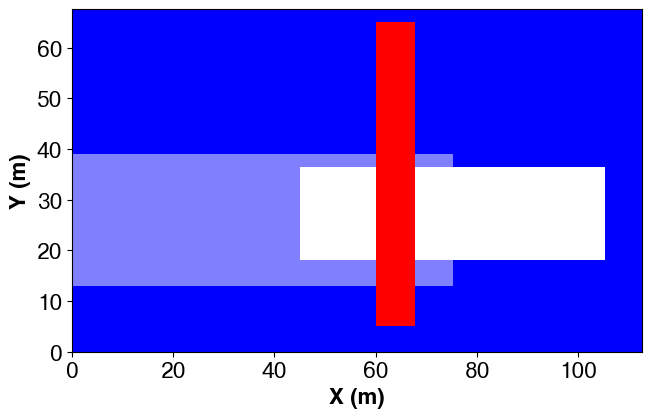

In [6]:
plt.imshow(param.T, cmap="bwr", extent=extent, origin="lower")
plt.xlabel("X (m)", fontweight="bold")
plt.ylabel("Y (m)", fontweight="bold")

- Add some noise to check all borders

In [7]:
# Add some noise with a seed
rng = np.random.default_rng(26659)
param += rng.random((nx, ny)) * 5.0

Text(0, 0.5, 'Y (m)')

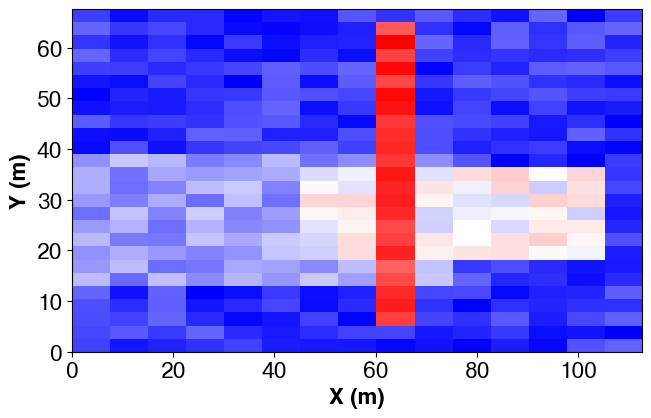

In [8]:
plt.imshow(param.T, cmap="bwr", extent=extent, origin="lower")
plt.xlabel("X (m)", fontweight="bold")
plt.ylabel("Y (m)", fontweight="bold")

## Tickonov regularisation

### Forward Difference Approximations


- Loss function computation

In [9]:
regularizator_tn_x = TikhonovRegularizatorAnisotropic(dx, axis=0)
regularizator_tn_y = TikhonovRegularizatorAnisotropic(dx, axis=1)
regularizator_tn_xy = TikhonovRegularizatorIsotropic(dx, dy)

print(f"jreg_tn_anisotropic_x = {regularizator_tn_x.loss_function(param)}")
print(f"jreg_tn_anisotropic_y = {regularizator_tn_y.loss_function(param)}")
print(f"jreg_tn_isotropic_xy = {regularizator_tn_xy.loss_function(param)}")

jreg_tn_anisotropic_x = 138.92326776349813
jreg_tn_anisotropic_y = 33.27560064398258
jreg_tn_isotropic_xy = 469.9609488203039


- Gradient computation and verification

In [10]:
# We check the formulation by finite differences for the three cases
for regularizator in [regularizator_tn_x, regularizator_tn_y, regularizator_tn_xy]:
    grad_tn_reg_fd = regularizator.loss_function_gradient(
        param, is_finite_differences=True
    )
    grad_tn_reg_analytic = regularizator.loss_function_gradient(param)
    np.testing.assert_allclose(grad_tn_reg_fd, grad_tn_reg_analytic, atol=1e-5)

In [11]:
grad_tn_x_fd = regularizator_tn_x.loss_function_gradient(param, True)
grad_tn_y_fd = regularizator_tn_y.loss_function_gradient(param, True)
grad_tn_xy_fd = regularizator_tn_xy.loss_function_gradient(param, True)

grad_tn_x_an = regularizator_tn_x.loss_function_gradient(param, False)
grad_tn_y_an = regularizator_tn_y.loss_function_gradient(param, False)
grad_tn_xy_an = regularizator_tn_xy.loss_function_gradient(param, False)

- Gradient plot (isotropic vs. anisotropic / finite difference vs. analytical)

Text(0.5, 0.98, 'Residuals (x1000)')

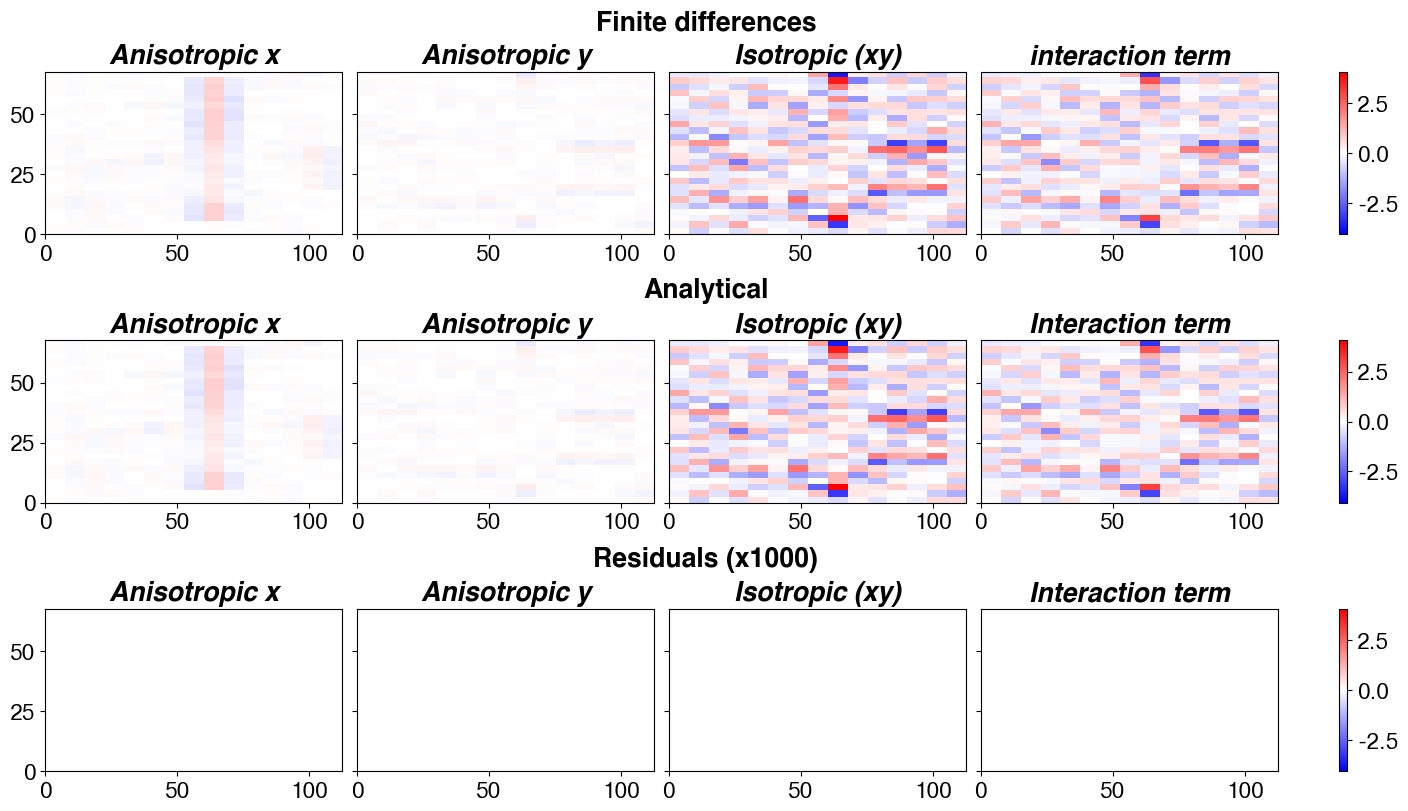

In [12]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (14, 8)},
    subfigs_params={"nrows": 3},
    subplots_mosaic_params={
        "fig0": dict(
            mosaic=[
                ["ax1-1", "ax1-2", "ax1-3", "ax1-4"],
            ],
            sharey=True,
            sharex=True,
        ),
        "fig1": dict(
            mosaic=[
                ["ax2-1", "ax2-2", "ax2-3", "ax2-4"],
            ],
            sharey=True,
            sharex=True,
        ),
        "fig2": dict(
            mosaic=[
                ["ax3-1", "ax3-2", "ax3-3", "ax3-4"],
            ],
            sharey=True,
            sharex=True,
        ),
    },
)

multi_imshow(
    list(plotter.grouped_ax_dict["fig0"].values()),
    plotter.fig,
    data={
        "Anisotropic x": grad_tn_x_fd,
        "Anisotropic y": grad_tn_y_fd,
        "Isotropic (xy)": grad_tn_xy_fd,
        "interaction term": grad_tn_xy_fd - grad_tn_x_fd - grad_tn_y_fd,
    },
    is_symetric_cbar=True,
    imshow_kwargs={
        "vmin": -np.max(np.abs(grad_tn_xy_fd)),
        "vmax": np.max(np.abs(grad_tn_xy_fd)),
        "extent": extent,
    },
)
plotter.subfigs["fig0"].suptitle("Finite differences", fontweight="bold")

multi_imshow(
    list(plotter.grouped_ax_dict["fig1"].values()),
    plotter.fig,
    data={
        "Anisotropic x": grad_tn_x_an,
        "Anisotropic y": grad_tn_y_an,
        "Isotropic (xy)": grad_tn_xy_an,
        "Interaction term": grad_tn_xy_an - grad_tn_x_an - grad_tn_y_an,
    },
    is_symetric_cbar=True,
    imshow_kwargs={
        "vmin": -np.max(np.abs(grad_tn_xy_fd)),
        "vmax": np.max(np.abs(grad_tn_xy_fd)),
        "extent": extent,
    },
)
plotter.subfigs["fig1"].suptitle("Analytical", fontweight="bold")

multi_imshow(
    list(plotter.grouped_ax_dict["fig2"].values()),
    plotter.fig,
    data={
        "Anisotropic x": (grad_tn_x_fd - grad_tn_x_an) * 1000,
        "Anisotropic y": (grad_tn_y_fd - grad_tn_y_an) * 1000,
        "Isotropic (xy)": (grad_tn_xy_fd - grad_tn_xy_an) * 1000,
        "Interaction term": (
            grad_tn_xy_fd
            - grad_tn_x_fd
            - grad_tn_y_fd
            - (grad_tn_xy_an - grad_tn_x_an - grad_tn_y_an)
        )
        * 1000,
    },
    is_symetric_cbar=True,
    imshow_kwargs={
        "vmin": -np.max(np.abs(grad_tn_xy_fd)),
        "vmax": np.max(np.abs(grad_tn_xy_fd)),
        "extent": extent,
    },
)
plotter.subfigs["fig2"].suptitle("Residuals (x1000)", fontweight="bold")

## Total Variation

- Loss function computation

In [13]:
regularizator_tv_x = TVRegularizatorAnisotropic(dx, axis=0, eps=1e-20)
regularizator_tv_y = TVRegularizatorAnisotropic(dy, axis=1, eps=1e-20)
regularizator_tv_xy = TVRegularizatorIsotropic(dx, dy, eps=1e-20)

print(f"jreg_tv_anisotropic_x = {regularizator_tv_x.loss_function(param)}")
print(f"jreg_tv_anisotropic_y = {regularizator_tv_y.loss_function(param)}")
print(f"jreg_tv_isotropic_xy = {regularizator_tv_xy.loss_function(param)}")

jreg_tv_anisotropic_x = 183.88445182900745
jreg_tv_anisotropic_y = 304.12524191104
jreg_tv_isotropic_xy = 411.6354159783299


- Gradient computation and verification

In [14]:
for regularizator in [regularizator_tv_x, regularizator_tv_y, regularizator_tv_xy]:
    grad_tv_reg_fd = regularizator.loss_function_gradient(
        param, is_finite_differences=True
    )
    grad_tv_reg_analytic = regularizator.loss_function_gradient(param)
    np.testing.assert_allclose(grad_tv_reg_fd, grad_tv_reg_analytic, atol=1e-5)

In [15]:
grad_tv_x_fd = regularizator_tv_x.loss_function_gradient(param, True)
grad_tv_y_fd = regularizator_tv_y.loss_function_gradient(param, True)
grad_tv_xy_fd = regularizator_tv_xy.loss_function_gradient(param, True)

grad_tv_x_an = regularizator_tv_x.loss_function_gradient(param, False)
grad_tv_y_an = regularizator_tv_y.loss_function_gradient(param, False)
grad_tv_xy_an = regularizator_tv_xy.loss_function_gradient(param, False)

- Gradient plot (isotropic vs. anisotropic / finite difference vs. analytical)

Text(0.5, 0.98, 'Residuals (x1000)')

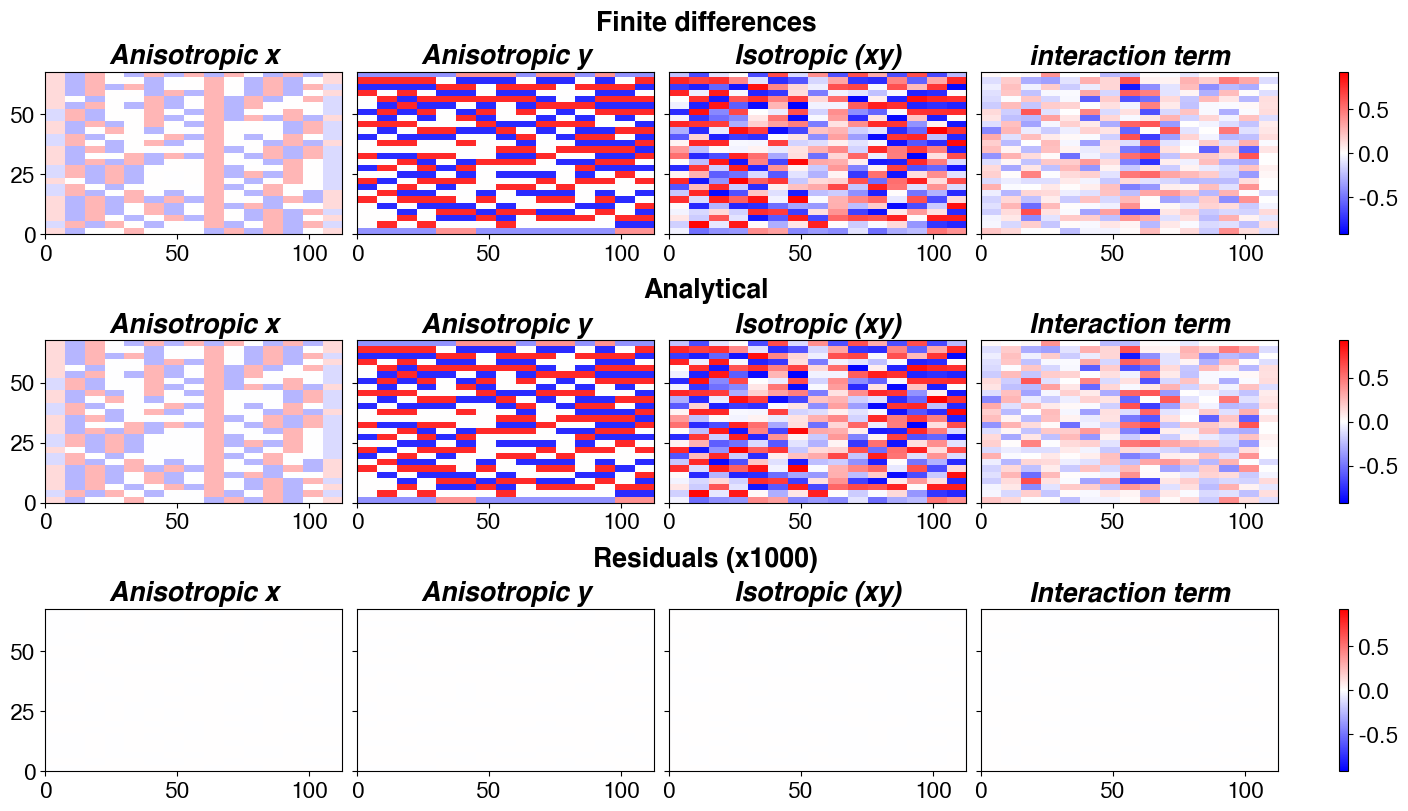

In [16]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (14, 8)},
    subfigs_params={"nrows": 3},
    subplots_mosaic_params={
        "fig0": dict(
            mosaic=[
                ["ax1-1", "ax1-2", "ax1-3", "ax1-4"],
            ],
            sharey=True,
            sharex=True,
        ),
        "fig1": dict(
            mosaic=[
                ["ax2-1", "ax2-2", "ax2-3", "ax2-4"],
            ],
            sharey=True,
            sharex=True,
        ),
        "fig2": dict(
            mosaic=[
                ["ax3-1", "ax3-2", "ax3-3", "ax3-4"],
            ],
            sharey=True,
            sharex=True,
        ),
    },
)

multi_imshow(
    list(plotter.grouped_ax_dict["fig0"].values()),
    plotter.fig,
    data={
        "Anisotropic x": grad_tv_x_fd,
        "Anisotropic y": grad_tv_y_fd,
        "Isotropic (xy)": grad_tv_xy_fd,
        "interaction term": grad_tv_xy_fd - grad_tv_x_fd - grad_tv_y_fd,
    },
    is_symetric_cbar=True,
    imshow_kwargs={
        "vmin": -np.max(np.abs(grad_tv_xy_fd)),
        "vmax": np.max(np.abs(grad_tv_xy_fd)),
        "extent": extent,
    },
)
plotter.subfigs["fig0"].suptitle("Finite differences", fontweight="bold")

multi_imshow(
    list(plotter.grouped_ax_dict["fig1"].values()),
    plotter.fig,
    data={
        "Anisotropic x": grad_tv_x_an,
        "Anisotropic y": grad_tv_y_an,
        "Isotropic (xy)": grad_tv_xy_an,
        "Interaction term": grad_tv_xy_an - grad_tv_x_an - grad_tv_y_an,
    },
    is_symetric_cbar=True,
    imshow_kwargs={
        "vmin": -np.max(np.abs(grad_tv_xy_fd)),
        "vmax": np.max(np.abs(grad_tv_xy_fd)),
        "extent": extent,
    },
)
plotter.subfigs["fig1"].suptitle("Analytical", fontweight="bold")

multi_imshow(
    list(plotter.grouped_ax_dict["fig2"].values()),
    plotter.fig,
    data={
        "Anisotropic x": (grad_tv_x_fd - grad_tv_x_an) * 1000,
        "Anisotropic y": (grad_tv_y_fd - grad_tv_y_an) * 1000,
        "Isotropic (xy)": (grad_tv_xy_fd - grad_tv_xy_an) * 1000,
        "Interaction term": (
            grad_tv_xy_fd
            - grad_tv_x_fd
            - grad_tv_y_fd
            - (grad_tv_xy_an - grad_tv_x_an - grad_tv_y_an)
        )
        * 1000,
    },
    is_symetric_cbar=True,
    imshow_kwargs={
        "vmin": -np.max(np.abs(grad_tv_xy_fd)),
        "vmax": np.max(np.abs(grad_tv_xy_fd)),
        "extent": extent,
    },
)
plotter.subfigs["fig2"].suptitle("Residuals (x1000)", fontweight="bold")